[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/SushrutGaikwad/svm-gmu/blob/main/examples/close_separable.ipynb)

# SVM-GMU: Training and Visualization Example

This notebook walks through a complete example of using the SVM-GMU classifier on a 2-D dataset with complex (banana- and crescent-shaped) Gaussian mixture uncertainties. The two classes are placed close to each other but are still linearly separable, so the uncertainty shapes have a noticeable effect on where the SVM-GMU decision boundary ends up compared to the standard SVM. The notebook covers:

1. **Defining the dataset:** Observed points, labels, and per-sample GMM uncertainty descriptions.
2. **Visualizing the uncertainty:** Plotting the GMM density contours before any training.
3. **Training SVM-GMU:** Fitting the uncertainty-aware classifier.
4. **Training a standard SVM:** Fitting without uncertainty for comparison.
5. **Plotting decision boundaries:** The SVM-GMU boundary alone, and a side-by-side comparison with the standard SVM.

In [1]:
%%capture

# Installing svm-gmu
!pip install git+https://github.com/SushrutGaikwad/svm-gmu.git

In [2]:
# Imports

import numpy as np
from svm_gmu import SvmGmu
from svm_gmu.plotting import plot_uncertainty, plot_boundary, plot_boundary_comparison

## 1. Define the dataset

We have $n = 6$ training samples in $d = 2$ dimensions. Three belong to class $+1$ and three to class $-1$. Each sample's uncertainty is modeled as a Gaussian mixture with between 5 and 6 components, giving rise to banana and crescent shapes in the density contours. Unlike a textbook dataset with widely separated clusters, here the two class regions sit quite close to one another. This makes the effect of uncertainty-awareness on the decision boundary easy to see.

### Observed feature vectors and class labels

In [3]:
X = np.array([
    [-1.8,  0.0],   # +1
    [-2.0,  1.5],   # +1
    [-1.0,  2.5],   # +1
    [ 1.5, -1.0],   # -1
    [ 1.0,  1.0],   # -1
    [ 2.0,  2.0],   # -1
])
y = np.array([+1, +1, +1, -1, -1, -1])

### Per-sample uncertainty descriptions

Each sample gets a GMM uncertainty dict with keys `"weights"`, `"means"`, and `"covariances"`. The component means are placed along curved arcs to create banana and crescent shapes, and each component's covariance is elongated along the local tangent of the curve.

In [4]:
sample_1 = {
    "weights": np.array([0.10, 0.20, 0.40, 0.20, 0.10]),
    "means": np.array([
        [-2.2 - 2,  1.2 - 1.5],
        [-1.8 - 2,  1.8 - 1.5],
        [-1.0 - 2,  2.0 - 1.5],
        [-0.2 - 2,  1.8 - 1.5],
        [ 0.2 - 2,  1.2 - 1.5],
    ]),
    "covariances": np.array([
        [[ 0.08, -0.05],
         [-0.05,  0.15]],
        [[ 0.10, -0.03],
         [-0.03,  0.12]],
        [[ 0.18,  0.00],
         [ 0.00,  0.06]],
        [[ 0.10,  0.03],
         [ 0.03,  0.12]],
        [[ 0.08,  0.05],
         [ 0.05,  0.15]],
    ]),
}

sample_2 = {
    "weights": np.array([0.08, 0.15, 0.22, 0.30, 0.15, 0.10]),
    "means": np.array([
        [-1.2 - 1,  1.6 - 1],
        [-0.8 - 1,  2.1 - 1],
        [-0.4 - 1,  2.5 - 1],
        [ 0.2 - 1,  2.7 - 1],
        [ 0.6 - 1,  2.5 - 1],
        [ 0.9 - 1,  2.1 - 1],
    ]),
    "covariances": np.array([
        [[ 0.07,  0.04],
         [ 0.04,  0.13]],
        [[ 0.09,  0.03],
         [ 0.03,  0.10]],
        [[ 0.14,  0.02],
         [ 0.02,  0.07]],
        [[ 0.18,  0.00],
         [ 0.00,  0.05]],
        [[ 0.12, -0.02],
         [-0.02,  0.07]],
        [[ 0.08, -0.04],
         [-0.04,  0.12]],
    ]),
}

sample_3 = {
    "weights": np.array([0.10, 0.20, 0.40, 0.20, 0.10]),
    "means": np.array([
        [-2.6 + 2,  2.2],
        [-2.2 + 2,  2.7],
        [-1.7 + 2,  3.0],
        [-1.2 + 2,  3.4],
        [-0.9 + 2,  3.8],
    ]),
    "covariances": np.array([
        [[ 0.14, -0.06],
         [-0.06,  0.08]],
        [[ 0.12, -0.07],
         [-0.07,  0.10]],
        [[ 0.10, -0.05],
         [-0.05,  0.14]],
        [[ 0.08,  0.03],
         [ 0.03,  0.16]],
        [[ 0.10,  0.06],
         [ 0.06,  0.15]],
    ]),
}

sample_4 = {
    "weights": np.array([0.08, 0.17, 0.25, 0.25, 0.17, 0.08]),
    "means": np.array([
        [ 0.6 - 1.5, -0.3],
        [ 1.0 - 1.5, -0.7],
        [ 1.4 - 1.5, -1.0],
        [ 1.9 - 1.5, -1.2],
        [ 2.3 - 1.5, -1.1],
        [ 2.6 - 1.5, -0.8],
    ]),
    "covariances": np.array([
        [[ 0.07,  0.04],
         [ 0.04,  0.12]],
        [[ 0.09,  0.03],
         [ 0.03,  0.10]],
        [[ 0.15,  0.00],
         [ 0.00,  0.07]],
        [[ 0.15,  0.00],
         [ 0.00,  0.07]],
        [[ 0.09, -0.03],
         [-0.03,  0.10]],
        [[ 0.12, -0.05],
         [-0.05,  0.09]],
    ]),
}

sample_5 = {
    "weights": np.array([0.10, 0.20, 0.40, 0.20, 0.10]),
    "means": np.array([
        [-0.2 + 1.5, -1.5 + 2.2],
        [ 0.2 + 1.5, -1.9 + 2.2],
        [ 0.8 + 1.5, -2.1 + 2.2],
        [ 1.4 + 1.5, -1.9 + 2.2],
        [ 1.8 + 1.5, -1.5 + 2.2],
    ]),
    "covariances": np.array([
        [[ 0.09,  0.05],
         [ 0.05,  0.14]],
        [[ 0.12,  0.03],
         [ 0.03,  0.10]],
        [[ 0.16,  0.00],
         [ 0.00,  0.07]],
        [[ 0.12, -0.03],
         [-0.03,  0.10]],
        [[ 0.09, -0.05],
         [-0.05,  0.14]],
    ]),
}

sample_6 = {
    "weights": np.array([0.08, 0.17, 0.25, 0.25, 0.17, 0.08]),
    "means": np.array([
        [ 0.9 + 1.5, -2.7 + 5],
        [ 1.3 + 1.5, -3.0 + 5],
        [ 1.8 + 1.5, -3.0 + 5],
        [ 2.3 + 1.5, -2.9 + 5],
        [ 2.7 + 1.5, -2.5 + 5],
        [ 2.9 + 1.5, -2.0 + 5],
    ]),
    "covariances": np.array([
        [[ 0.08,  0.05],
         [ 0.05,  0.11]],
        [[ 0.12,  0.03],
         [ 0.03,  0.08]],
        [[ 0.15,  0.00],
         [ 0.00,  0.06]],
        [[ 0.13, -0.02],
         [-0.02,  0.07]],
        [[ 0.09, -0.04],
         [-0.04,  0.10]],
        [[ 0.07, -0.05],
         [-0.05,  0.12]],
    ]),
}

sample_uncertainty = [sample_1, sample_2, sample_3,
                      sample_4, sample_5, sample_6]

## 2. Visualize the uncertainty (data only)

Before training any model, we can inspect the dataset using `plot_uncertainty`. Each sample's GMM density is shown as nested filled contours at the $1\sigma$, $2\sigma$, $3\sigma$, and $4\sigma$ levels.

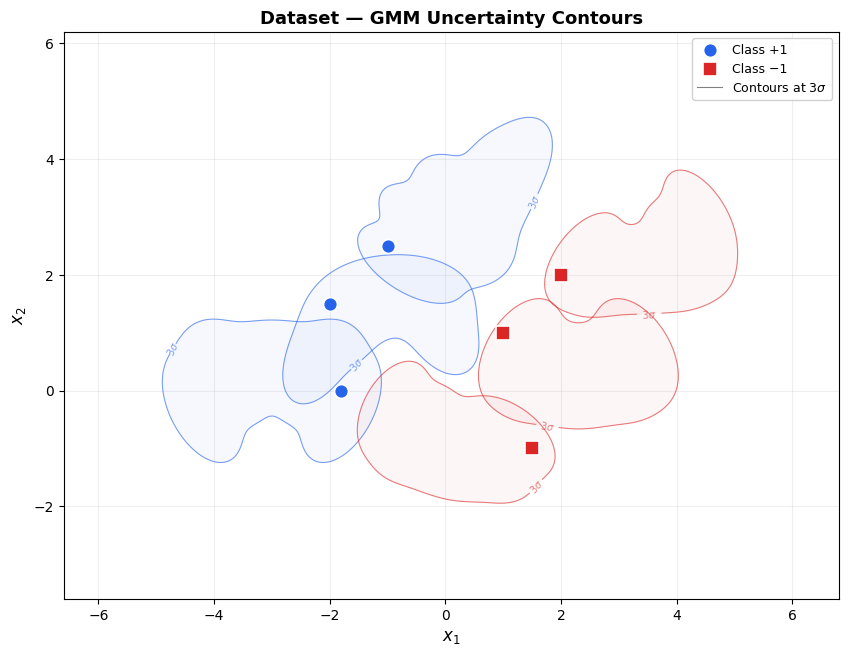

In [5]:
fig, ax = plot_uncertainty(
    X, y, sample_uncertainty,
    sigmas=(3,),
    figsize=(10, 10),
    title="Dataset — GMM Uncertainty Contours",
)

The blue contours (class $+1$) and red contours (class $-1$) show where the classifier believes the true location of each sample might lie. The banana and crescent shapes are clearly visible, and you can see that the two class regions are close to one another but do not overlap at the plotted sigma levels.

## 3. Train SVM-GMU (uncertainty-aware)

We now train the SVM-GMU model, passing the full GMM uncertainty for each sample. We use full-batch SGD (`batch_size=6`, since $n = 6$) for stable convergence.

In [6]:
model_gmu = SvmGmu(
    lam=0.01,
    max_iter=1000,
    batch_size=6,
    random_state=42,
    verbose=True,
    log_interval=100,
)
model_gmu.fit(X, y, sample_uncertainty=sample_uncertainty)

  iter    100 / 1000  |  objective = 0.047382
  iter    200 / 1000  |  objective = 0.047231
  iter    300 / 1000  |  objective = 0.047229
  iter    400 / 1000  |  objective = 0.047228
  iter    500 / 1000  |  objective = 0.047228
  iter    600 / 1000  |  objective = 0.047228
  iter    700 / 1000  |  objective = 0.047228
  iter    800 / 1000  |  objective = 0.047228
  iter    900 / 1000  |  objective = 0.047228
  iter   1000 / 1000  |  objective = 0.047228


SvmGmu(batch_size=6, random_state=42, verbose=True)

In [7]:
print(f"\nSVM-GMU:  w = {model_gmu.coef_},  b = {model_gmu.intercept_:.4f}")


SVM-GMU:  w = [-1.25267325  1.25886418],  b = -0.9470


## 4. Train a standard SVM (no uncertainty)

For comparison, we train the same model without any uncertainty information. When `sample_uncertainty` is omitted, each sample is treated as a point mass and the model reduces to a standard linear SVM.

In [8]:
model_svm = SvmGmu(
    lam=0.01,
    max_iter=5000,
    batch_size=6,
    random_state=42,
    verbose=True,
    log_interval=1000,
)
model_svm.fit(X, y)

  iter   1000 / 5000  |  objective = 0.003760
  iter   2000 / 5000  |  objective = 0.003755
  iter   3000 / 5000  |  objective = 0.003610
  iter   4000 / 5000  |  objective = 0.003668
  iter   5000 / 5000  |  objective = 0.003662


SvmGmu(batch_size=6, log_interval=1000, max_iter=5000, random_state=42,
       verbose=True)

In [9]:
print(f"\nStd SVM:   w = {model_svm.coef_},  b = {model_svm.intercept_:.4f}")


Std SVM:   w = [-0.81062493  0.25751718],  b = -0.4547


## 5. Plot the SVM-GMU decision boundary

`plot_boundary` overlays the learned decision boundary (solid black line at $\mathbf{w}^\intercal \mathbf{x} + b = 0$) and the margin lines (dashed at $\pm 1$) on top of the uncertainty contours.

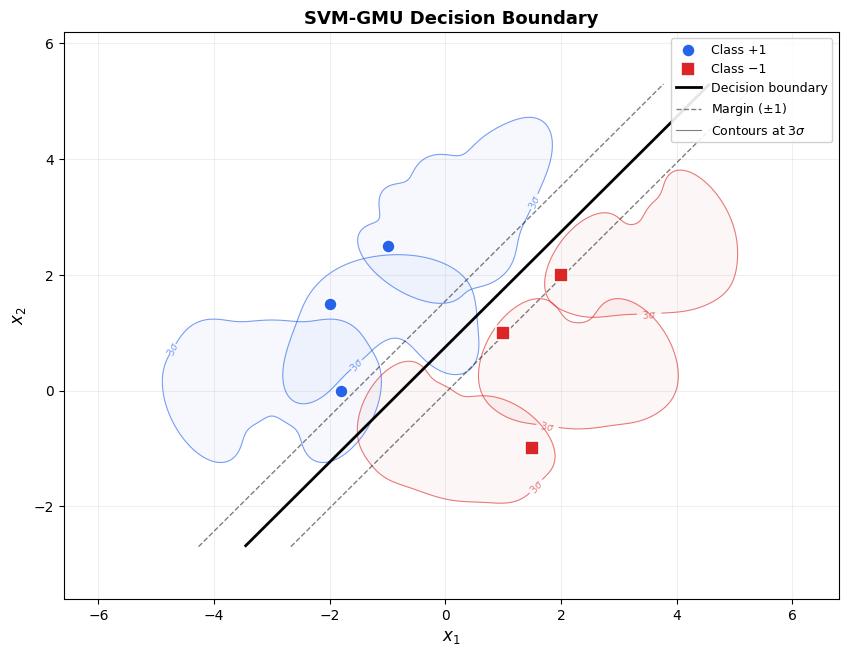

In [10]:
fig, ax = plot_boundary(
    X, y, sample_uncertainty, model_gmu,
    sigmas=(3,),
    figsize=(10, 10),
    title="SVM-GMU Decision Boundary",
)

## 6. Compare SVM-GMU vs. standard SVM

`plot_boundary_comparison` overlays the two boundaries on the same plot. The SVM-GMU boundary (solid black) is drawn as the main model, with the Standard SVM boundary (dashed orange) shown as the comparison. Seeing them together makes it easy to see how uncertainty-aware training shifts the decision boundary relative to the standard SVM.

By default, margin lines are hidden to keep the plot uncluttered. If you want them, pass `show_margins="gmu"`, `"svm"`, or `"both"`.

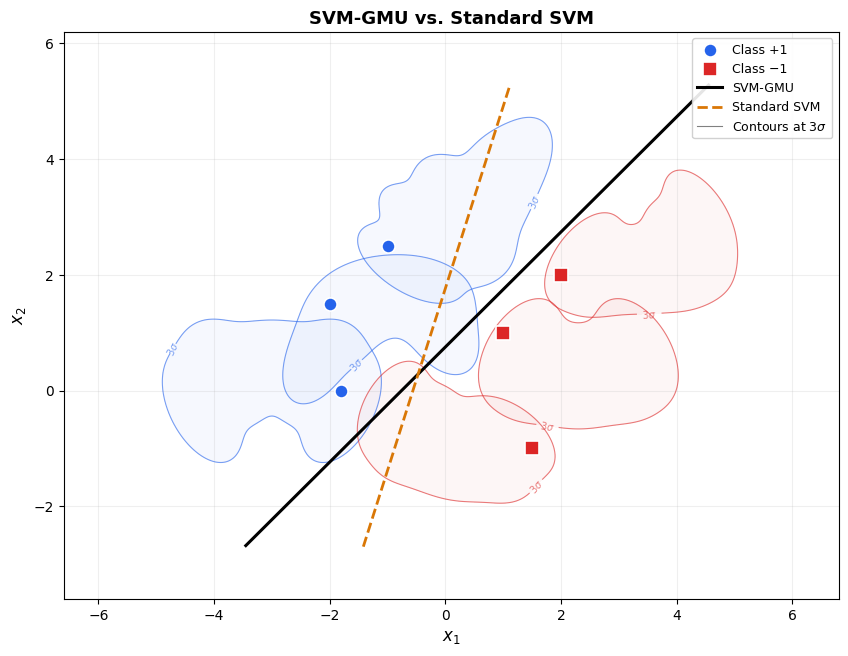

In [11]:
fig, ax = plot_boundary_comparison(
    X, y, sample_uncertainty,
    model_gmu, model_svm,
    sigmas=(3,),
)

## 7. Check predictions

Both models predict using the standard hyperplane rule $\hat{y} = \mathrm{sign}(\mathbf{w}^\intercal \mathbf{x} + b)$. No uncertainty is used at prediction time.

In [12]:
print("SVM-GMU predictions:", model_gmu.predict(X))
print("Std SVM  predictions:", model_svm.predict(X))

SVM-GMU predictions: [ 1.  1.  1. -1. -1. -1.]
Std SVM  predictions: [ 1.  1.  1. -1. -1. -1.]


In [13]:
print("SVM-GMU decision scores:", np.round(model_gmu.decision_function(X), 4))
print("Std SVM  decision scores:", np.round(model_svm.decision_function(X), 4))

SVM-GMU decision scores: [ 1.3078  3.4466  3.4528 -4.0849 -0.9408 -0.9346]
Std SVM  decision scores: [ 1.0044  1.5528  0.9997 -1.9281 -1.0078 -1.5609]
